In [1]:
import sys
from pathlib import Path

_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof"))
del petab_base_files["condition_table"]

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= perbb2.mean()
del proteomics

In [2]:
cytof_dynamic, _, _, _ = load_data(
    contextualization="cytof_dynamic",
    samples=samples,
    features=None,
    **petab_base_files,
)

In [3]:
cytof_dynamic.sort_index()["pERBB2_Y1248_obs", "EGF", 0.0]

preequilibrationConditionId
c184A1      4.166056
c184B5      4.378879
cAU565      4.130444
cBT20       4.475806
cBT474      5.086383
              ...   
cUACC812    4.191278
cUACC893         NaN
cZR751      4.355707
cZR7530     4.952224
cZR75B      4.332784
Name: (pERBB2_Y1248_obs, EGF, 0.0), Length: 63, dtype: float64

In [4]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

subtypes_marcotte = pd.read_csv("./../../cell_line_subtypes.txt", delimiter='\t')
subtypes_marcotte["cell_line"] = subtypes_marcotte["cell_line"].apply(lambda x: "c"+x.upper())
subtypes_marcotte["cell_line"] = subtypes_marcotte["cell_line"].replace("cHS578T", "cHs578T")
subtypes_marcotte["cell_line"] = subtypes_marcotte["cell_line"].replace("c600MPE", "cMPE600")
subtypes_marcotte.sort_values(by="cell_line", inplace=True)
subtypes_marcotte.set_index("cell_line", inplace=True)
subtypes_marcotte = subtypes_marcotte.loc[samples]

In [5]:
df = pd.concat([tegfr.rename("tEGFR"), pegfr.rename("pEGFR")], axis=1)
df.sort_index(inplace=True)
df["pam50_marcotte"] = subtypes_marcotte["subtype_intrinsic"].loc[df.index]

In [6]:
from common import subtypes_tognetti

subtypes_lb = {cell_line: subtypes_tognetti[cell_line]["Luminal/Basal"] for cell_line in subtypes_tognetti.keys()}
subtypes_pam50 = {cell_line: subtypes_tognetti[cell_line]["PAM50"] for cell_line in subtypes_tognetti.keys()}

df["lb"] = df.index.map(subtypes_lb)
df["pam50"] = df.index.map(subtypes_pam50)

In [7]:
df["pam50_marcotte"] = df["pam50_marcotte"].fillna("Unknown")

In [8]:
df["lb_marcotte"] = df["pam50_marcotte"]
df["lb_marcotte"] = df["lb_marcotte"].replace(["LuminalA", "LuminalB"], "Luminal")
df["lb_marcotte"] = df["lb_marcotte"].replace(["CL"], "Basal")
df["lb_marcotte"] = df["lb_marcotte"].replace(["HER2"], "Luminal")

In [9]:
from sklearn.svm import SVC

svc = SVC(kernel="linear")
svc.fit(df[["tEGFR"]].to_numpy(), df["lb_marcotte"].to_numpy())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
svc.score(df[["tEGFR"]].to_numpy(), df["lb_marcotte"].to_numpy())

0.7301587301587301

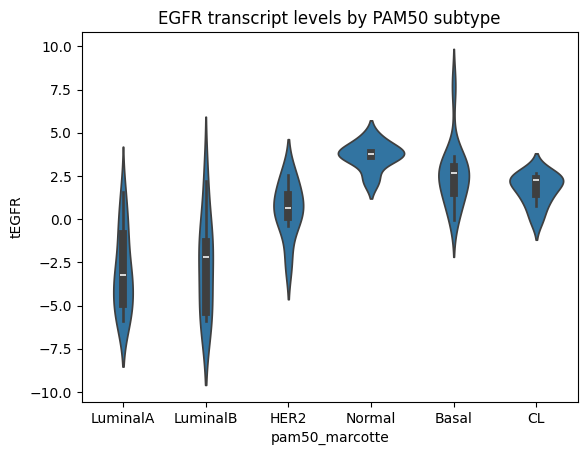

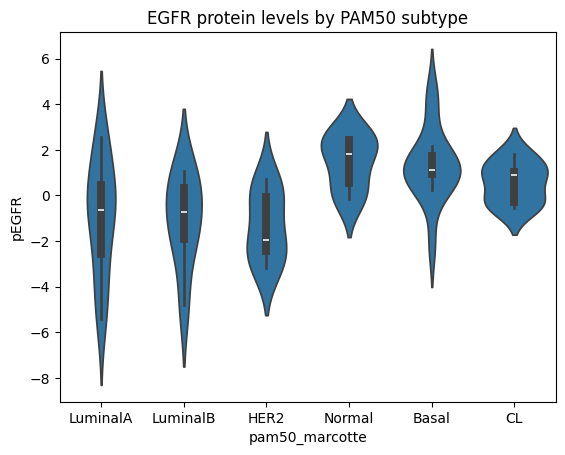

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tEGFR",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("EGFR transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="pEGFR",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("EGFR protein levels by PAM50 subtype")
plt.show()

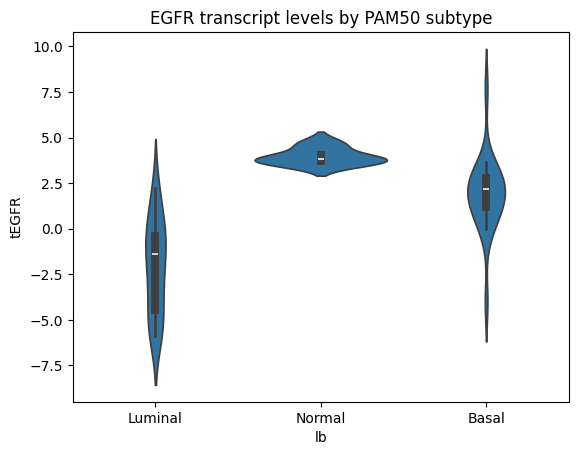

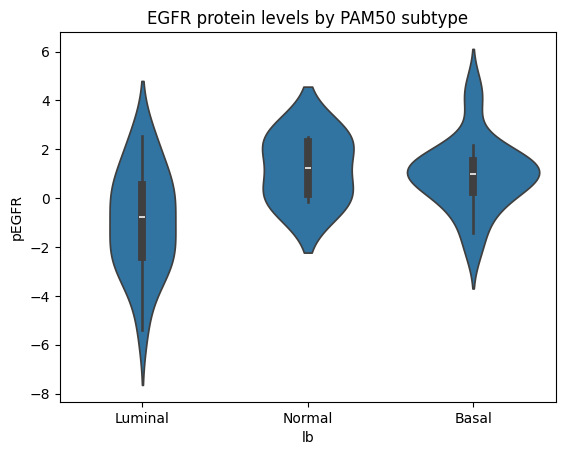

In [12]:
sns.violinplot(
    df,
    x="lb",
    y="tEGFR",
    order=["Luminal", "Normal", "Basal"]
).set_title("EGFR transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="lb",
    y="pEGFR",
    order=["Luminal", "Normal", "Basal"]
).set_title("EGFR protein levels by PAM50 subtype")
plt.show()

# Since pERK downregulates EGFR transcription, are pERK and tEGFR anti-correlated (cytof_init/transcriptomics)

In [13]:
cytof_init, _, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)
perk = cytof_init["p.ERK"]
perk -= perk.mean()
del cytof_init

In [14]:
comp_df = perk.copy().reset_index().set_index("preequilibrationConditionId")
comp_df.sort_index(inplace=True)
tegfr.sort_index(inplace=True)

comp_df["tEGFR"] = tegfr

comp_df["subtype_marcotte"] = subtypes_marcotte["subtype_intrinsic"].loc[comp_df.index]
comp_df["subtype_lb"] = subtypes_marcotte["subtype_intrinsic"].loc[comp_df.index]
comp_df["subtype_lb"] = comp_df["subtype_lb"].replace(["LuminalA", "LuminalB"], "Luminal")
comp_df["subtype_lb"] = comp_df["subtype_lb"].replace(["CL"], "Basal")
comp_df["subtype_lb"] = comp_df["subtype_lb"].replace(["HER2"], "Luminal")

In [15]:
comp_df

,p.ERK,tEGFR,subtype_marcotte,subtype_lb
preequilibrationConditionId,,,,
c184A1,-0.264948,3.869841,Normal,Normal
c184B5,-0.571457,4.638841,Normal,Normal
cAU565,0.073309,2.526841,HER2,Luminal
cBT20,0.930046,3.038841,Basal,Basal
cBT474,0.214535,-0.775159,LuminalA,Luminal
...,...,...,...,...
cUACC812,-0.100992,-4.899159,LuminalA,Luminal
cUACC893,-0.341886,0.959841,HER2,Luminal
cZR751,0.304553,-0.716159,LuminalA,Luminal


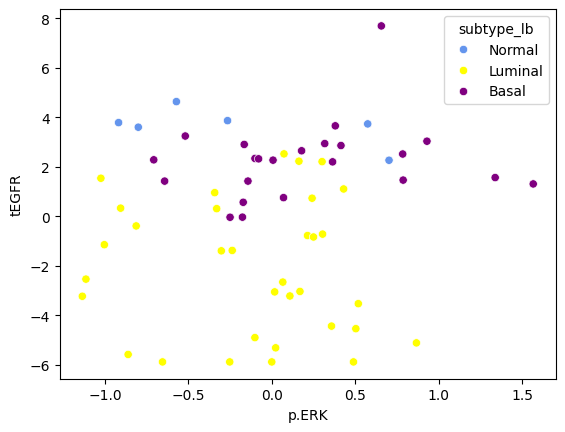

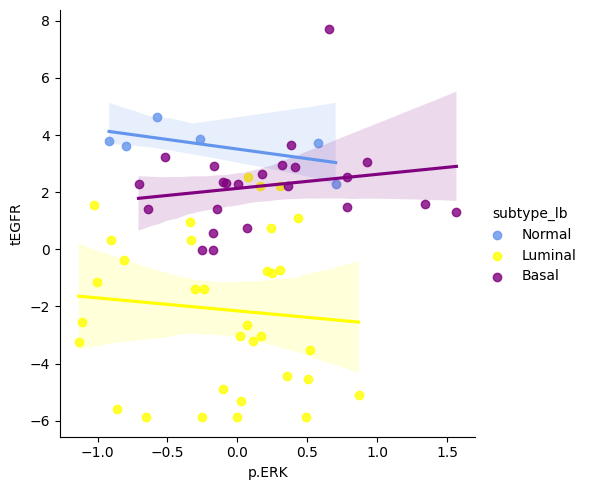

In [16]:
sns.scatterplot(
    comp_df,
    x="p.ERK",
    y="tEGFR",
    hue="subtype_lb",
    palette={
        "Luminal": "yellow",
        "Normal": "cornflowerblue",
        "Basal": "purple"
    }
)
plt.show()

sns.lmplot(
    comp_df,
    x="p.ERK",
    y="tEGFR",
    hue="subtype_lb",
    palette={
        "Luminal": "yellow",
        "Normal": "cornflowerblue",
        "Basal": "purple"
    }
)
plt.show()

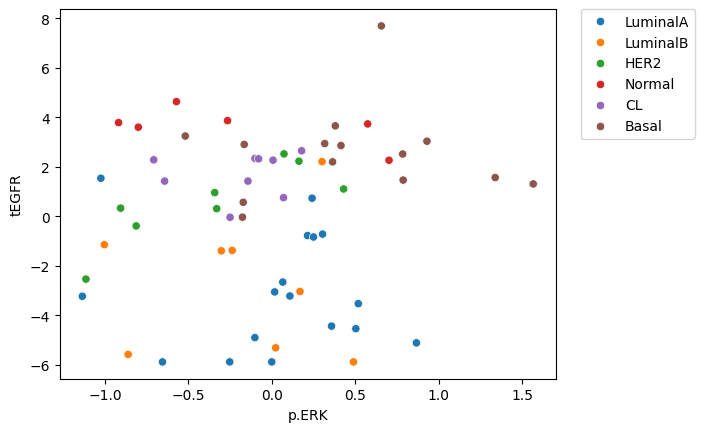

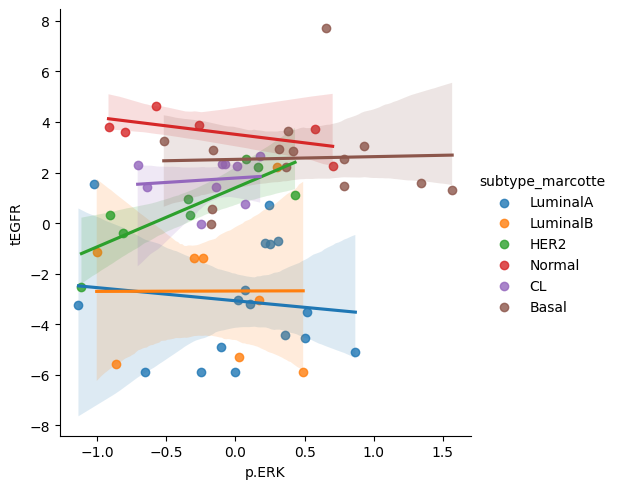

In [17]:
sns.scatterplot(
    comp_df,
    x="p.ERK",
    y="tEGFR",
    hue="subtype_marcotte",
    hue_order=["LuminalA", "LuminalB", "HER2", "Normal", "CL", "Basal"],
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

sns.lmplot(
    comp_df,
    x="p.ERK",
    y="tEGFR",
    hue="subtype_marcotte",
    hue_order=["LuminalA", "LuminalB", "HER2", "Normal", "CL", "Basal"]
)
plt.show()

In [18]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs_tegfr_aggavg", data="dream_cytof"))
del petab_base_files["condition_table"]

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
# Caveolin
tcav1 = transcriptomics["CAV1"]
tcav1 -= tcav1.mean()
tcav2 = transcriptomics["CAV1"]
tcav2 -= tcav2.mean()

tatp2c2 = transcriptomics["ATP2C2"]
tatp2c2 -= tatp2c2.mean()
tzg16b = transcriptomics["ZG16B"]
tzg16b -= tzg16b.mean()
tpls3 = transcriptomics["PLS3"]
tpls3 -= tpls3.mean()
tclip4 = transcriptomics["CLIP4"]
tclip4 -= tclip4.mean()
tcdh1 = transcriptomics["CDH1"]
tcdh1 -= tcdh1.mean()
trhot1 = transcriptomics["RHOT1"]
trhot1 -= trhot1.mean()
trhot2 = transcriptomics["RHOT2"]
trhot2 -= trhot2.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pisoc1 = proteomics["ISOC1"]
pisoc1 -= pisoc1.mean()
pbaz1a = proteomics["BAZ1A"]
pbaz1a -= pbaz1a.mean()
pfasn = proteomics["FASN"]
pfasn -= pfasn.mean()
pergic1 = proteomics["ERGIC1"]
pergic1 -= pergic1.mean()
pcdh1 = proteomics["CDH1"]
pcdh1 -= pcdh1.mean()
prhot1 = proteomics["RHOT1"]
prhot1 -= prhot1.mean()
prhot2 = proteomics["RHOT2"]
prhot2 -= prhot2.mean()
del proteomics

In [19]:
df = pd.concat(
    [
        tcav1.rename("tCAV1"),
        tcav2.rename("tCAV2"),
        tatp2c2.rename("tATP2C2"),
        tzg16b.rename("tZG16B"),
        tpls3.rename("tPLS3"),
        tclip4.rename("tCLIP4"),
        tcdh1.rename("tCDH1"),
        trhot1.rename("tRHOT1"),
        trhot2.rename("tRHOT2"),
        pisoc1.rename("pISOC1"),
        pbaz1a.rename("pBAZ1A"),
        pfasn.rename("pFASN"),
        pergic1.rename("pERGIC1"),
        pcdh1.rename("pCDH1"),
        prhot1.rename("pRHOT1"),
        prhot2.rename("pRHOT2"),
    ], axis=1)
df.sort_index(inplace=True)
df["pam50_marcotte"] = subtypes_marcotte["subtype_intrinsic"].loc[df.index]
df["lb_marcotte"] = df["pam50_marcotte"]
df["lb_marcotte"] = df["lb_marcotte"].replace(["LuminalA", "LuminalB"], "Luminal")
df["lb_marcotte"] = df["lb_marcotte"].replace(["CL"], "Basal")
df["lb_marcotte"] = df["lb_marcotte"].replace(["HER2"], "Luminal")

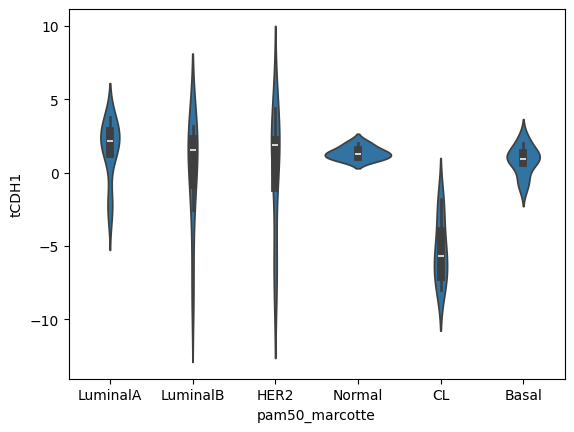

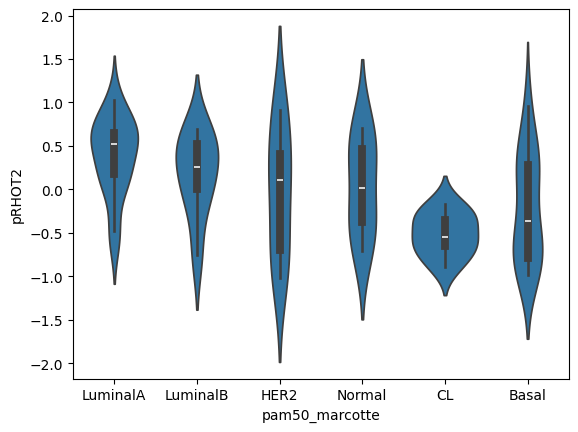

In [20]:
sns.violinplot(
    df,
    x="pam50_marcotte",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "CL", "Basal"],
    y="tCDH1"
)
plt.show()


sns.violinplot(
    df,
    x="pam50_marcotte",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "CL", "Basal"],
    y="pRHOT2"
)
plt.show()


<Axes: xlabel='tCAV1', ylabel='tCAV2'>

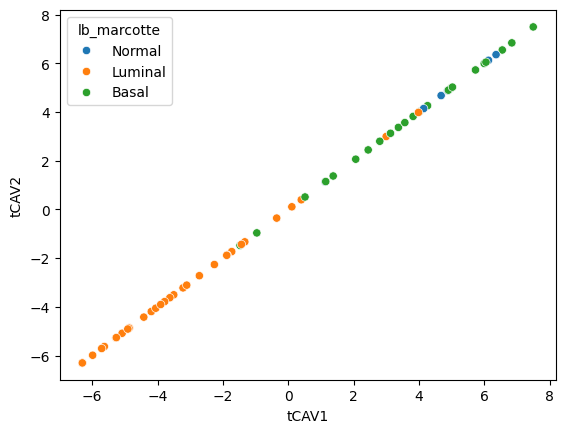

In [21]:
sns.scatterplot(
    df,
    x="tCAV1",
    y="tCAV2",
    hue="lb_marcotte",
)

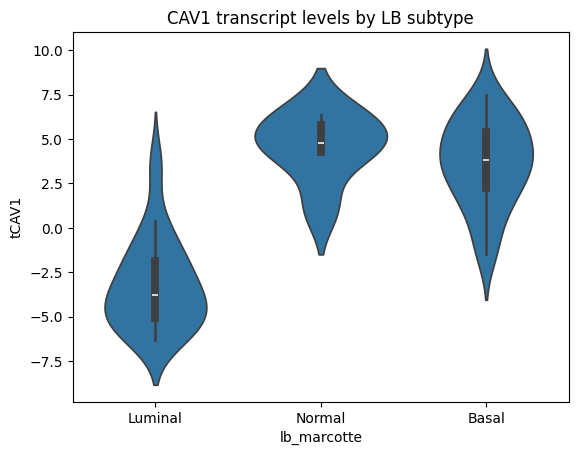

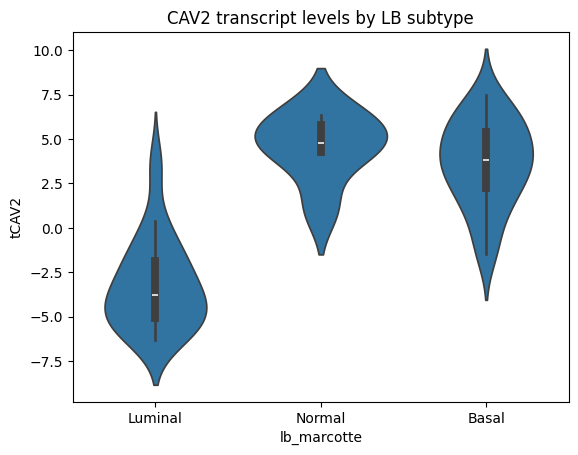

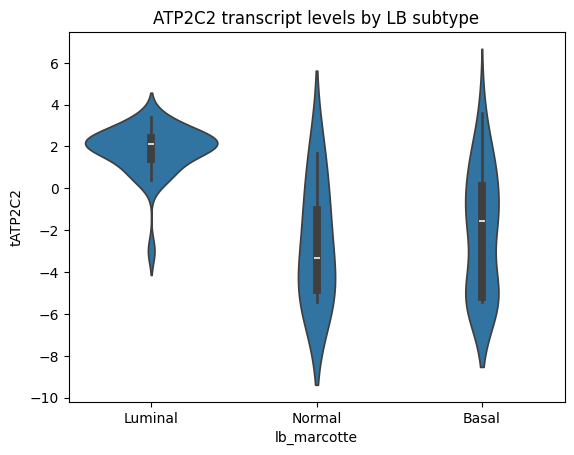

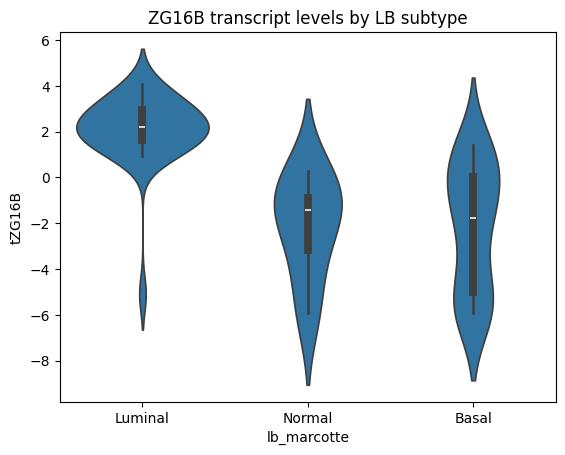

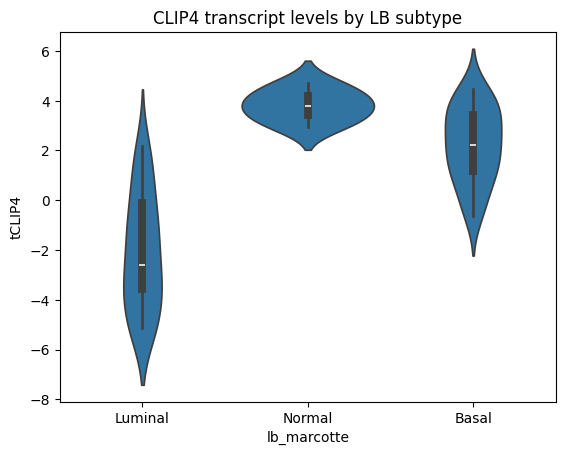

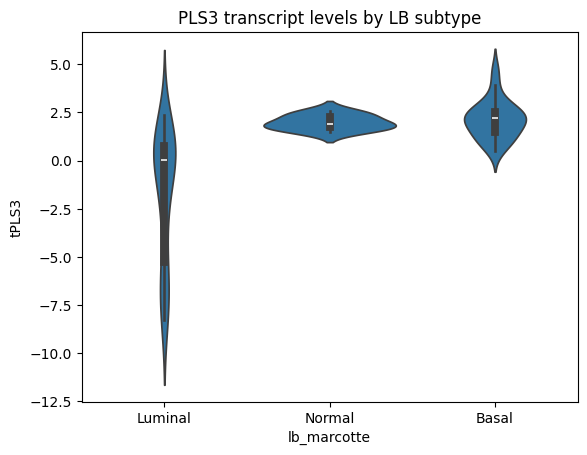

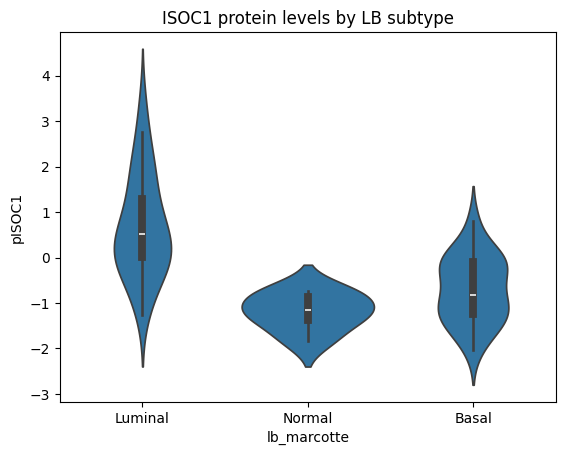

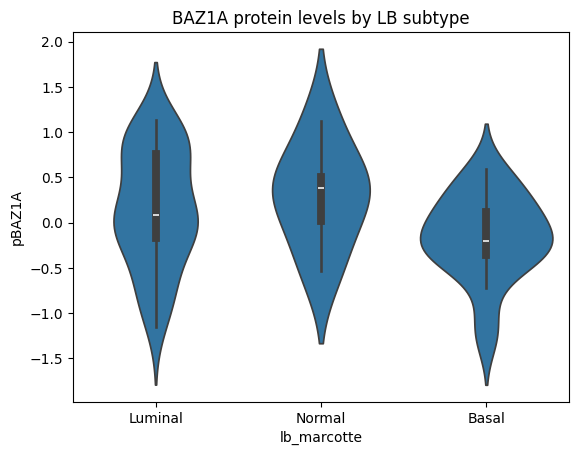

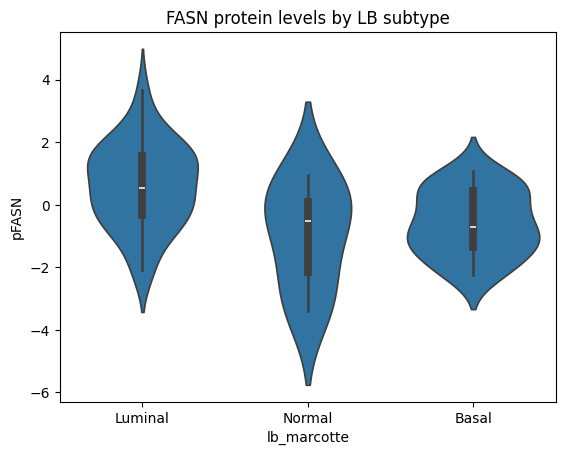

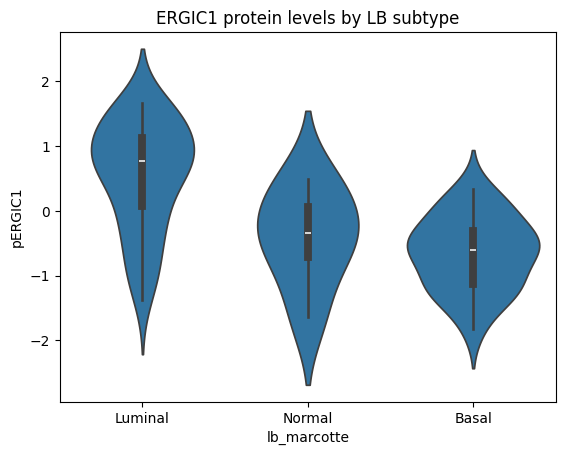

In [22]:
sns.violinplot(
    df,
    x="lb_marcotte",
    y="tCAV1",
    order=["Luminal", "Normal", "Basal"]
).set_title("CAV1 transcript levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="tCAV2",
    order=["Luminal", "Normal", "Basal"]
).set_title("CAV2 transcript levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="tATP2C2",
    order=["Luminal", "Normal", "Basal"]
).set_title("ATP2C2 transcript levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="tZG16B",
    order=["Luminal", "Normal", "Basal"]
).set_title("ZG16B transcript levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="tCLIP4",
    order=["Luminal", "Normal", "Basal"]
).set_title("CLIP4 transcript levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="tPLS3",
    order=["Luminal", "Normal", "Basal"]
).set_title("PLS3 transcript levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="pISOC1",
    order=["Luminal", "Normal", "Basal"]
).set_title("ISOC1 protein levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="pBAZ1A",
    order=["Luminal", "Normal", "Basal"]
).set_title("BAZ1A protein levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="pFASN",
    order=["Luminal", "Normal", "Basal"]
).set_title("FASN protein levels by LB subtype")
plt.show()

sns.violinplot(
    df,
    x="lb_marcotte",
    y="pERGIC1",
    order=["Luminal", "Normal", "Basal"]
).set_title("ERGIC1 protein levels by LB subtype")
plt.show()

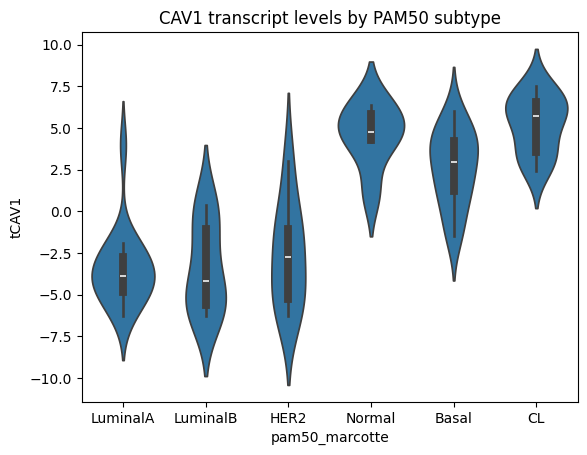

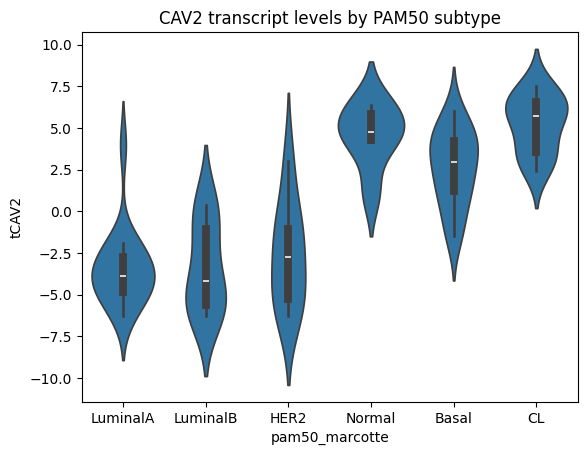

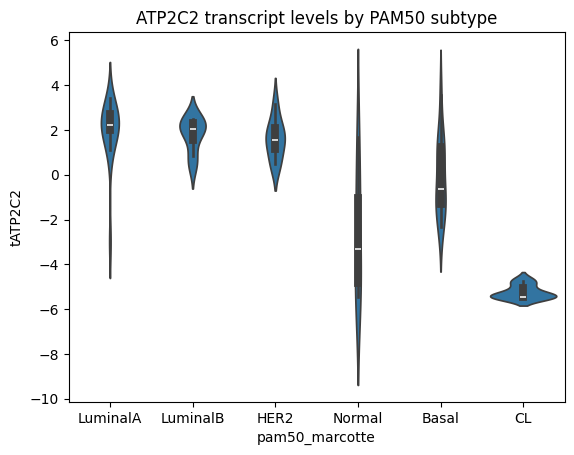

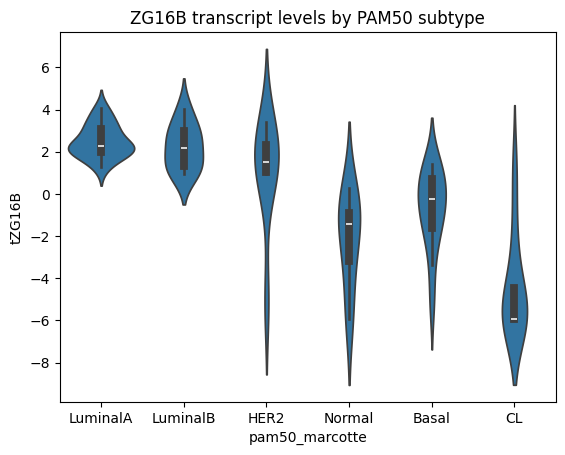

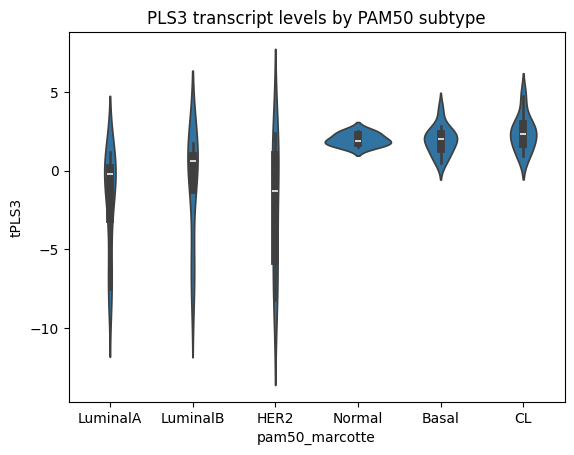

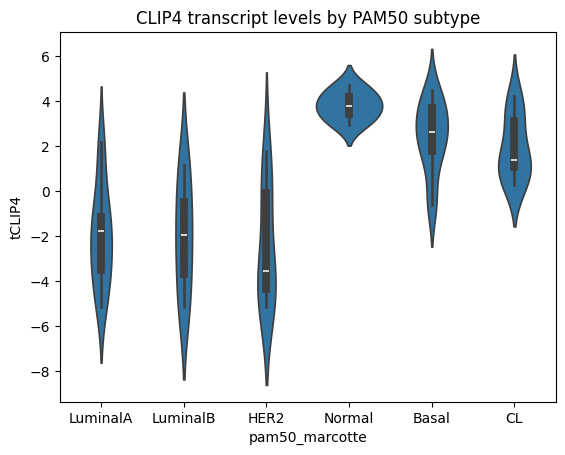

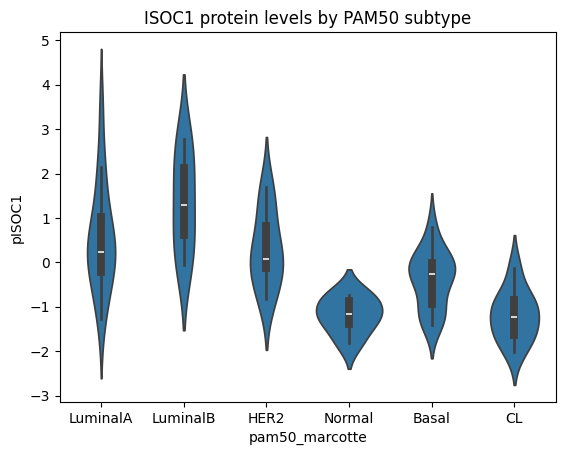

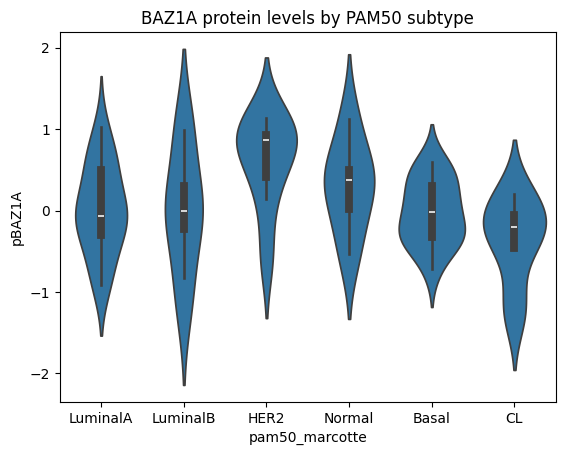

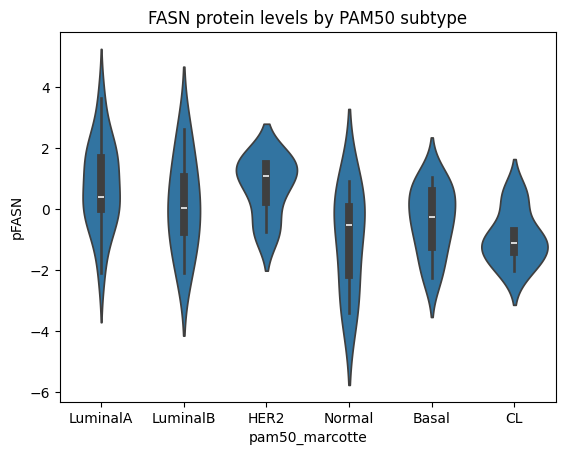

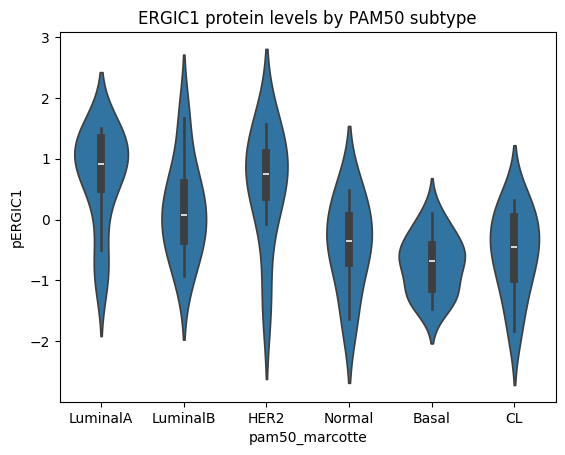

In [23]:
sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tCAV1",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("CAV1 transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tCAV2",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("CAV2 transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tATP2C2",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("ATP2C2 transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tZG16B",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("ZG16B transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tPLS3",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("PLS3 transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="tCLIP4",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("CLIP4 transcript levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="pISOC1",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("ISOC1 protein levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="pBAZ1A",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("BAZ1A protein levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="pFASN",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("FASN protein levels by PAM50 subtype")
plt.show()

sns.violinplot(
    df,
    x="pam50_marcotte",
    y="pERGIC1",
    order=["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
).set_title("ERGIC1 protein levels by PAM50 subtype")
plt.show()

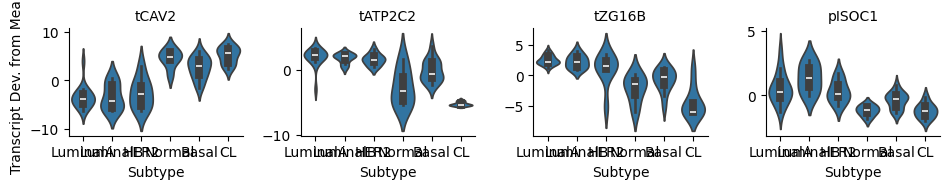

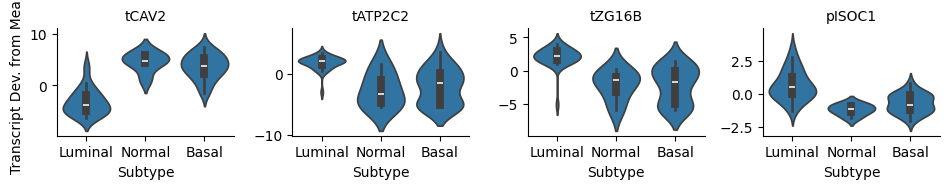

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Reshape to long format
markers = ["tCAV2", "tATP2C2", "tZG16B", "pISOC1", "pFASN", "tCLIP4", "tPLS3"]
df_long = df.melt(
    id_vars=["pam50_marcotte", "lb_marcotte"],
    value_vars=markers,
    var_name="marker",
    value_name="expression"
)

# Define row orders
pam50_order = ["LuminalA", "LuminalB", "HER2", "Normal", "Basal", "CL"]
lb_order = ["Luminal", "Normal", "Basal"]

# --- PAM50 version ---
g = sns.FacetGrid(
    df_long,
    col="marker",
    col_order=["tCAV2", "tATP2C2", "tZG16B", "pISOC1"],
    sharey=False,
    margin_titles=True,
    height=2.0,
    aspect=1.2
)
g.map(sns.violinplot, "pam50_marcotte", "expression", order=pam50_order,
      inner="box", scale="width")
g.set_axis_labels("Subtype", "Transcript Dev. from Mean")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.subplots_adjust(hspace=0.5)
plt.show()

# --- LB version ---
g = sns.FacetGrid(
    df_long,
    col="marker",
    col_order=["tCAV2", "tATP2C2", "tZG16B", "pISOC1"],
    sharey=False,
    margin_titles=True,
    height=2.0,
    aspect=1.2
)
g.map(sns.violinplot, "lb_marcotte", "expression", order=lb_order,
      inner="box", scale="width")
g.set_axis_labels("Subtype", "Transcript Dev. from Mean")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.subplots_adjust(hspace=0.5)
plt.show()

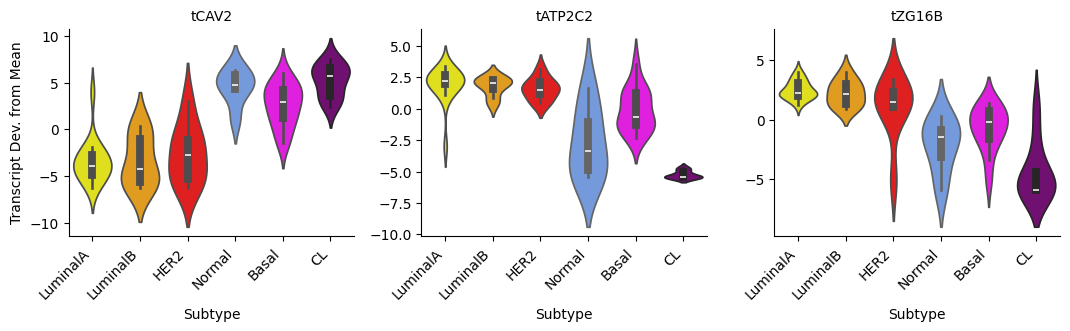

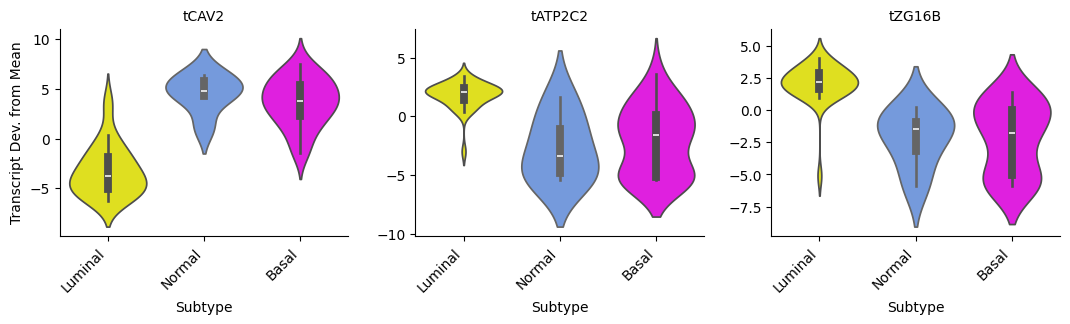

In [25]:
# --- PAM50 version ---
g = sns.FacetGrid(
    df_long,
    col="marker",
    col_order=["tCAV2", "tATP2C2", "tZG16B"],
    sharey=False,
    margin_titles=True,
    height=3.0,
    aspect=1.2,
    hue="pam50_marcotte",
    palette={
        "LuminalA": "yellow",
        "LuminalB": "orange",
        "HER2": "red",
        "Basal": "magenta",
        "CL": "purple",
        "Normal": "cornflowerblue"
    },
)
g.map(
    sns.violinplot,
    "pam50_marcotte",
    "expression",
    order=pam50_order,
    inner="box",
    scale="width"
)
g.set_axis_labels("Subtype", "Transcript Dev. from Mean")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# rotate xtick labels across all facets
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.subplots_adjust(hspace=0.5)
plt.savefig("pam50_transcripts_multimodal_subtype_divide.svg")
plt.show()


# --- LB version ---
g = sns.FacetGrid(
    df_long,
    col="marker",
    col_order=["tCAV2", "tATP2C2", "tZG16B"],
    sharey=False,
    margin_titles=True,
    height=3.0,
    aspect=1.2,
    hue="lb_marcotte",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
)
g.map(
    sns.violinplot,
    "lb_marcotte",
    "expression",
    order=lb_order,
    inner="box",
    scale="width",
)
g.set_axis_labels("Subtype", "Transcript Dev. from Mean")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# rotate xtick labels
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.subplots_adjust(hspace=0.5)
# plt.savefig("lb_transcripts_multimodal_subtype_divide.svg")
plt.show()

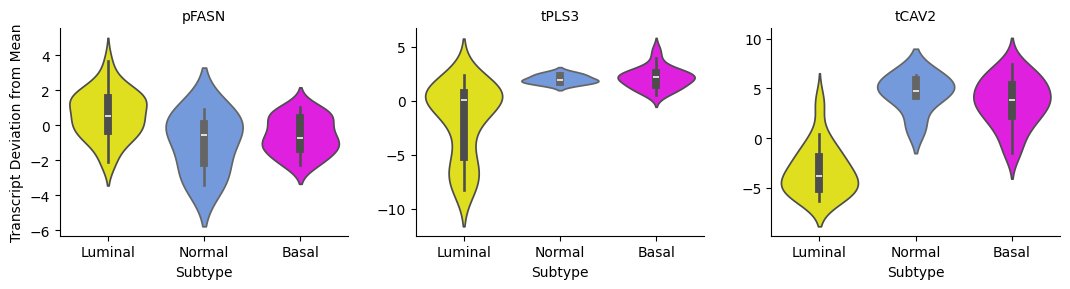

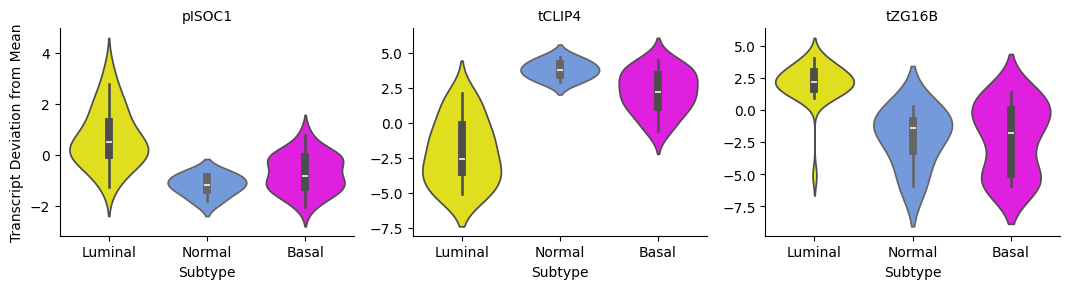

In [26]:
# First line of markers
g = sns.FacetGrid(
    df_long,
    col="marker",
    col_order=["pFASN", "tPLS3", "tCAV2"],
    sharey=False,
    margin_titles=True,
    height=3.0,
    aspect=1.2,
    hue="lb_marcotte",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
)
g.map(
    sns.violinplot,
    "lb_marcotte",
    "expression",
    order=lb_order,
    inner="box",
)
g.set_axis_labels("Subtype", "Transcript Deviation from Mean")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# rotate xtick labels across all facets
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels())

plt.subplots_adjust(hspace=0.5)
plt.savefig("lb_markers_EGFR_contexts_pt1.svg")
plt.show()


# Second line of markers
g = sns.FacetGrid(
    df_long,
    col="marker",
    col_order=["pISOC1", "tCLIP4", "tZG16B"],
    sharey=False,
    margin_titles=True,
    height=3.0,
    aspect=1.2,
    hue="lb_marcotte",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
)
g.map(
    sns.violinplot,
    "lb_marcotte",
    "expression",
    order=lb_order,
    inner="box",
)
g.set_axis_labels("Subtype", "Transcript Deviation from Mean")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# rotate xtick labels
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels())

plt.subplots_adjust(hspace=0.5)
plt.savefig("lb_markers_EGFR_contexts_pt2.svg")
plt.show()